In [1]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
x,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [4]:
df = pd.DataFrame({'feature1':x[:,0],'feature2':x[:,1],'target':y})

In [5]:
df.shape

(100, 3)

In [6]:
df.head()

,feature1,feature2,target
0,-0.550148,1.656076,126.664429
1,1.082593,1.015521,131.180105
2,-2.177542,-0.130253,-283.580939
3,0.449084,0.731353,74.093155
4,0.135274,-0.159572,-94.589686


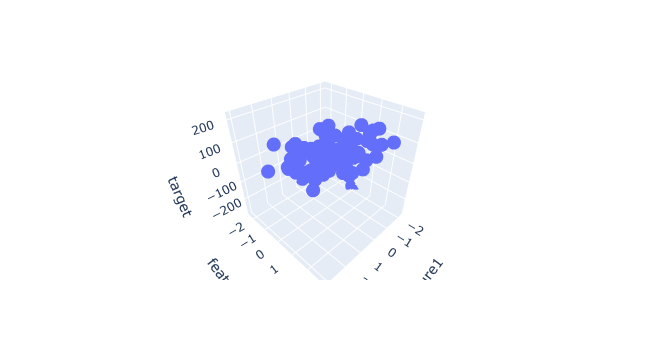

In [7]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.show()

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=3)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = lr.predict(x_test)

In [13]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 46.941078476476754
MSE 2872.760189029424
R2 score 0.7976198280767139


In [15]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

z = z_final

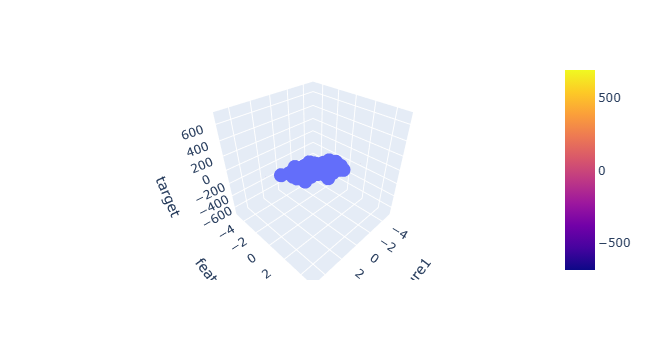

In [16]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z = z))

fig.show()

In [17]:
lr.coef_

array([51.85161126, 86.0656693 ])

In [18]:
lr.intercept_

np.float64(4.1046919986707024)